## Experiment 7
## Bagging, Boosting, and Stacked Ensemble Models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

# Loading and Basic Data Analysis 

In [2]:
def load_dataset(filepath, column_names=None, separator=","):
    df = pd.read_csv(filepath, names=column_names, sep=separator)
    df.columns = df.columns.str.strip()
    return df

def dataset_info(df):
    print("-" * 50)
    print("DATASET INFORMATION")
    print("-" * 50)
    print("\nShape: ", df.shape)
    print("\nColumns: ")
    print(df.columns.tolist())
    print("\nData Types: ")
    print(df.dtypes)
    print("\nMemory information")
    df.info()
    print("\nFirst 5 elements")
    print(df.head())

def missing_values(df):
    missing = df.isnull().sum()
    percent = (missing / len(df)) * 100
    result = pd.DataFrame({"missing": missing, "percent": percent})
    print(result)
    if missing.sum() == 0:
        print("There is no missing value!")
    else:
        print("\033[31mMissing Values detected\033[0m")
    return result

def duplicate_info(df):
    duplicates = df.duplicated().sum()
    print("\nThe duplicate rows are : ", duplicates)
    if duplicates == 0:
        print("No duplicates detected!")
    else:
        print("\033[31mDuplicates are detected\033[0m")
    return duplicates

def summary_statistics(df):
    print("\nSummary statistics")
    print(df.describe())

def class_distribution(df, target_column):
    print("\nClass Distribution")
    counts = df[target_column].value_counts()
    ax = counts.plot(kind="bar")
    plt.xlabel(target_column)
    plt.ylabel("Count")
    plt.title(f"Class Distribution of {target_column}")
    for container in ax.containers:
        ax.bar_label(container)
    plt.show()
    return counts

def plot_histogram(df, bins=10):
    numeric_df = df.select_dtypes("number")
    if "id" in numeric_df.columns:
        numeric_df = numeric_df.drop(columns=["id"])
    numeric_df.hist(bins=bins, figsize=(16, 12))
    plt.suptitle("Histogram of numerical features")
    plt.tight_layout()
    plt.show()

def plot_heatmap(df, max_annot_cols=10):
    numeric_df = df.select_dtypes("number")
    if "id" in numeric_df.columns:
        numeric_df = numeric_df.drop(columns=["id"])
    num_vars = len(numeric_df.columns)
    corr = numeric_df.corr()
    show_annot = num_vars <= max_annot_cols
    fig_width = max(8, num_vars * 0.45)
    fig_height = max(6, num_vars * 0.40)
    plt.figure(figsize=(fig_width, fig_height))
    sns.heatmap(corr, annot=show_annot, fmt=".2f", annot_kws={"size": 8},
                cmap="coolwarm", center=0, linewidths=0.5 if num_vars < 25 else 0)
    plt.title("Feature Correlation Heatmap")
    plt.tight_layout()
    plt.show()

def perform_eda(filepath, column_names=None, separator=",", categorical_columns=None):
    df = load_dataset(filepath, column_names=column_names, separator=separator)
    print("\nLoading dataset completed\n")
    dataset_info(df)
    missing_values(df)
    duplicate_info(df)
    summary_statistics(df)
    plot_histogram(df)
    plot_heatmap(df)
    if categorical_columns is not None:
        for col in categorical_columns:
            class_distribution(df, col)
    return df

# EDA Analysis


Loading dataset completed

--------------------------------------------------
DATASET INFORMATION
--------------------------------------------------

Shape:  (569, 32)

Columns: 
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst']

Data Types: 
id                           int64
diagnosis                      str
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            floa

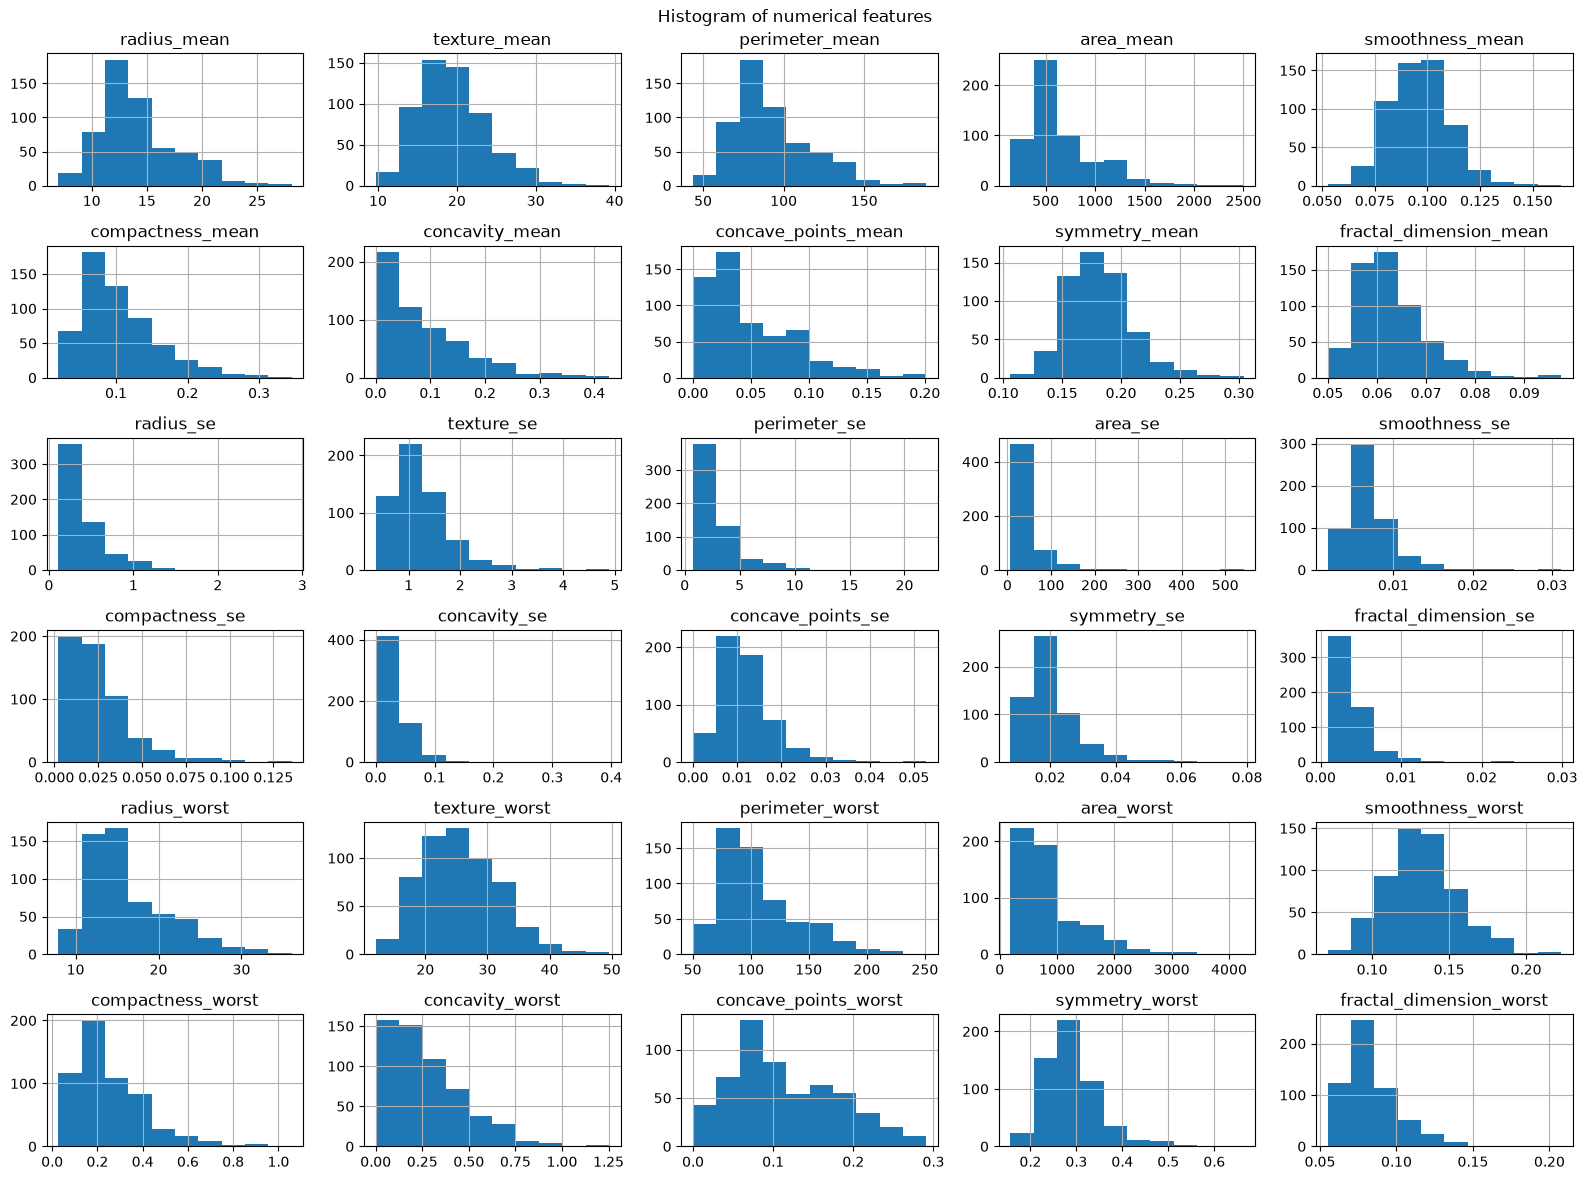

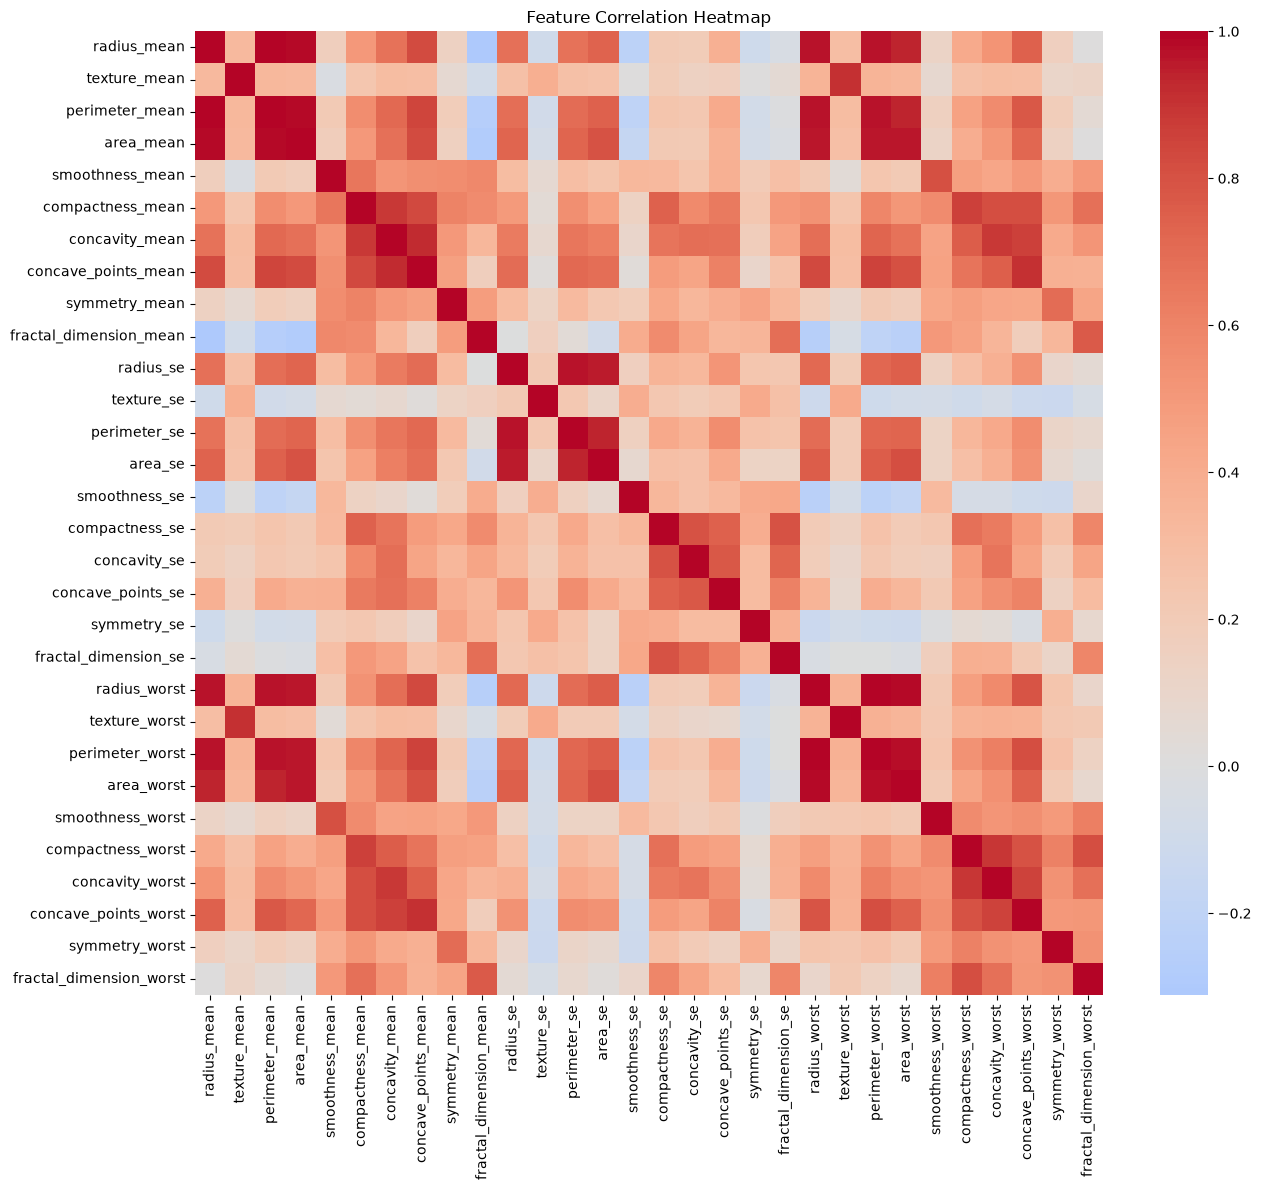


Class Distribution


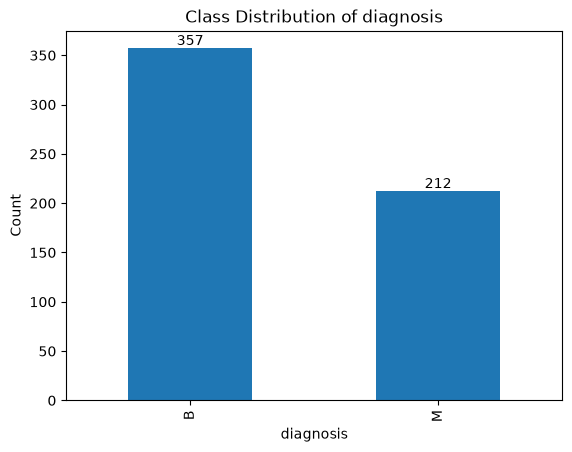

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
features = [
    "radius", "texture", "perimeter", "area", "smoothness",
    "compactness", "concavity", "concave_points", "symmetry", "fractal_dimension"
]
column_names = ["id", "diagnosis"]
for suffix in ["_mean", "_se", "_worst"]:
    column_names.extend([f"{feat}{suffix}" for feat in features])

df = perform_eda("datasets/wdbc.data", column_names=column_names,
                 categorical_columns=["diagnosis"])
display(df.head())

## Encode Class Labels and Train-Test Split

Class labels `M` (Malignant) and `B` (Benign) are encoded to numeric values. The `id` column is dropped as it is not a meaningful feature.

In [4]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

encoder = LabelEncoder()
df['diagnosis'] = encoder.fit_transform(df['diagnosis'])
print("Encoded Classes: ",dict(zip(encoder.classes_,encoder.transform(encoder.classes_))))

X = df.drop(['diagnosis','id'],axis=1)
# display(X.head())
y=df['diagnosis']
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("Train Shape: ",X_train.shape,"| Test shape:",X_test.shape)

Encoded Classes:  {'B': np.int64(0), 'M': np.int64(1)}
Train Shape:  (455, 30) | Test shape: (114, 30)


# Implement a Bagging classifier using a base estimator.


In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

base_model = DecisionTreeClassifier(random_state=42)
bagging_model = BaggingClassifier(estimator=base_model,n_estimators=10,max_samples=1.0,
                                  max_features=1.0,random_state=42)

bagging_model.fit(X_train,y_train)
y_pred = bagging_model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

print("Bagging Classifier Results")
print()
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nConfusion Matrix:")
print(cm)

Bagging Classifier Results

Accuracy : 0.956140350877193
Precision: 0.9523809523809523
Recall   : 0.9302325581395349
F1 Score : 0.9411764705882353

Confusion Matrix:
[[69  2]
 [ 3 40]]


# Implement Boosting classifiers (AdaBoost and/or Gradient Boosting)

## AdaBoost

In [6]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(n_estimators=50,learning_rate=1.0,
                               random_state=42)
ada_model.fit(X_train,y_train)

y_pred_ada = ada_model.predict(X_test)

In [7]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,
f1_score,confusion_matrix)

print("The Results from adagraad are: ")
print("--------------------")
print("Accuracy: ",accuracy_score(y_test,y_pred_ada))
print("Precision: ",precision_score(y_test,y_pred_ada))
print("Recall: ",recall_score(y_test,y_pred_ada))
print("F1 Score: ",f1_score(y_test,y_pred_ada))

print("The confusion matrix is: ")
print(confusion_matrix(y_test,y_pred_ada))

The Results from adagraad are: 
--------------------
Accuracy:  0.9649122807017544
Precision:  0.975609756097561
Recall:  0.9302325581395349
F1 Score:  0.9523809523809523
The confusion matrix is: 
[[70  1]
 [ 3 40]]


## Gradient Boosting

In [8]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model=GradientBoostingClassifier(n_estimators=50,learning_rate=0.1,
                                    max_depth=3,random_state=42)

gb_model.fit(X_train,y_train)
y_pred_gb = gb_model.predict(X_test)

In [9]:
print("Gradient Boosting results")
print("-------------")
print("Accuracy :", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall   :", recall_score(y_test, y_pred_gb))
print("F1 Score :", f1_score(y_test, y_pred_gb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

Gradient Boosting results
-------------
Accuracy : 0.956140350877193
Precision: 0.9523809523809523
Recall   : 0.9302325581395349
F1 Score : 0.9411764705882353

Confusion Matrix:
[[69  2]
 [ 3 40]]


# Stacked Ensemble Model

## Creating base model

In [10]:
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV

In [11]:
# Svm base model
calibrated_svc = CalibratedClassifierCV(estimator=SVC(random_state=42), ensemble=False)

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", calibrated_svc)
])

# Naive Bayes
nb_model = GaussianNB()

# Decision Tree
dt_model = DecisionTreeClassifier(random_state = 42)


In [12]:
from sklearn.ensemble import StackingClassifier
base_models = [ ("svm",svm_model),("nb",nb_model),("dt",dt_model)]
stacking_model=StackingClassifier(
    estimators= base_models,
    final_estimator=LogisticRegression(),
    cv=5)
stacking_model.fit(X_train,y_train)
y_pred_stack = stacking_model.predict(X_test)

In [13]:
print("Stacked Ensemble")
print("----------------")
print("Accuracy :", accuracy_score(y_test, y_pred_stack))
print("Precision:", precision_score(y_test, y_pred_stack))
print("Recall   :", recall_score(y_test, y_pred_stack))
print("F1 Score :", f1_score(y_test, y_pred_stack))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_stack))

Stacked Ensemble
----------------
Accuracy : 0.9649122807017544
Precision: 0.975609756097561
Recall   : 0.9302325581395349
F1 Score : 0.9523809523809523

Confusion Matrix:
[[70  1]
 [ 3 40]]


# Define Hyperparameter Search Space

In [14]:
bagging_param_grid = {
    "n_estimators": [10, 25, 50, 100],
    "max_samples": [0.5, 0.75, 1.0],
    "max_features": [0.5, 0.75, 1.0]
}

ada_param_grid = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.1, 0.5, 1.0],
    "estimator__max_depth": [1, 2, 3]
}

gb_param_grid = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.1, 0.5],
    "max_depth": [1, 2, 3]
}

print("Bagging Search Space:")
print(bagging_param_grid)

print("\nAdaBoost Search Space:")
print(ada_param_grid)

print("\nGradient Boosting Search Space:")
print(gb_param_grid)

Bagging Search Space:
{'n_estimators': [10, 25, 50, 100], 'max_samples': [0.5, 0.75, 1.0], 'max_features': [0.5, 0.75, 1.0]}

AdaBoost Search Space:
{'n_estimators': [50, 100, 150], 'learning_rate': [0.01, 0.1, 0.5, 1.0], 'estimator__max_depth': [1, 2, 3]}

Gradient Boosting Search Space:
{'n_estimators': [50, 100, 150], 'learning_rate': [0.01, 0.1, 0.5], 'max_depth': [1, 2, 3]}


## 1. Grid Search Hyperparameter tuning for **Bagging**

In [15]:
from sklearn.model_selection import GridSearchCV
bagging_grid = GridSearchCV(
    estimator=bagging_model,
    param_grid=bagging_param_grid,
    cv=5,
    scoring={
        "accuracy": "accuracy",
        "f1": "f1"
    },
    refit="accuracy",
    n_jobs=-1,
    verbose=1
)
bagging_grid.fit(X_train,y_train)
print("Best Parameters:")
print(bagging_grid.best_params_)

print("\nBest CV Accuracy:")
print(bagging_grid.best_score_)
print(bagging_grid.cv_results_.keys())

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters:
{'max_features': 0.5, 'max_samples': 0.75, 'n_estimators': 25}

Best CV Accuracy:
0.9604395604395604
dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_max_features', 'param_max_samples', 'param_n_estimators', 'params', 'split0_test_accuracy', 'split1_test_accuracy', 'split2_test_accuracy', 'split3_test_accuracy', 'split4_test_accuracy', 'mean_test_accuracy', 'std_test_accuracy', 'rank_test_accuracy', 'split0_test_f1', 'split1_test_f1', 'split2_test_f1', 'split3_test_f1', 'split4_test_f1', 'mean_test_f1', 'std_test_f1', 'rank_test_f1'])


In [16]:
bagging_cv_results = pd.DataFrame(bagging_grid.cv_results_)
bagging_results_table = bagging_cv_results[
     [
        "param_n_estimators",
        "param_max_samples",
        "param_max_features",
        "mean_test_accuracy",
        "mean_test_f1",
        "std_test_accuracy",
        "rank_test_accuracy"
    ]
].sort_values("rank_test_accuracy")

display(bagging_results_table)

best_bagging_model = bagging_grid.best_estimator_
print("Best Bagging Model:")
print(best_bagging_model)

,param_n_estimators,param_max_samples,param_max_features,mean_test_accuracy,mean_test_f1,std_test_accuracy,rank_test_accuracy
5,25,0.75,0.50,0.960440,0.945584,0.014906,1
22,50,1.00,0.75,0.960440,0.945688,0.005383,1
10,50,1.00,0.50,0.958242,0.942763,0.012815,3
9,25,1.00,0.50,0.958242,0.942948,0.010767,3
11,100,1.00,0.50,0.956044,0.938863,0.015541,5
8,10,1.00,0.50,0.956044,0.938838,0.017024,5
7,100,0.75,0.50,0.956044,0.939155,0.015541,5
6,50,0.75,0.50,0.956044,0.939150,0.013900,5
23,100,1.00,0.75,0.956044,0.939051,0.009829,5
19,100,0.75,0.75,0.953846,0.935886,0.014579,10


Best Bagging Model:
BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  max_features=0.5, max_samples=0.75, n_estimators=25,
                  random_state=42)


## 2. Gradient Search Hyperparameter tuning for **Boosting**

In [17]:
from sklearn.model_selection import GridSearchCV
gb_grid = GridSearchCV(
    estimator=gb_model,
    param_grid=gb_param_grid,
    cv=5,
    scoring={
        "accuracy": "accuracy",
        "f1": "f1"
    },
    refit="accuracy",
    n_jobs=-1,
    verbose=1
)

display(gb_grid.fit(X_train,y_train))


print("Best Gradient Boosting Parameters:")
print(gb_grid.best_params_)

print("\nBest CV Accuracy:")
print(gb_grid.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [1, 2, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",

Best Gradient Boosting Parameters:
{'learning_rate': 0.5, 'max_depth': 1, 'n_estimators': 100}

Best CV Accuracy:
0.9780219780219781


In [18]:
# All CV results

gb_cv_results = pd.DataFrame(gb_grid.cv_results_)

gb_results_table = gb_cv_results[
    [
        "param_n_estimators",
        "param_learning_rate",
        "param_max_depth",
        "mean_test_accuracy",
        "mean_test_f1",
        "std_test_accuracy",
        "rank_test_accuracy"
    ]
].sort_values("rank_test_accuracy")

display(gb_results_table)

,param_n_estimators,param_learning_rate,param_max_depth,mean_test_accuracy,mean_test_f1,std_test_accuracy,rank_test_accuracy
19,100,0.50,1,0.978022,0.969690,0.019658,1
20,150,0.50,1,0.973626,0.963427,0.022628,2
11,150,0.10,1,0.971429,0.960640,0.014906,3
18,50,0.50,1,0.971429,0.960819,0.014906,3
10,100,0.10,1,0.967033,0.954838,0.009829,5
26,150,0.50,3,0.964835,0.951127,0.016150,6
9,50,0.10,1,0.962637,0.947751,0.017855,7
17,150,0.10,3,0.962637,0.948219,0.013187,7
23,150,0.50,2,0.960440,0.945633,0.016447,9
25,100,0.50,3,0.960440,0.945516,0.017855,9


In [19]:
# Best tuned model

best_gb_model = gb_grid.best_estimator_

print("Best Gradient Boosting Model:")
print(best_gb_model)

Best Gradient Boosting Model:
GradientBoostingClassifier(learning_rate=0.5, max_depth=1, random_state=42)


## Hyperparameter tuning for stacking 

In [20]:
stacking_configurations = {
    "SVM + Naive Bayes": [
        ("svm", svm_model),
        ("nb", nb_model)
    ],

    "SVM + Decision Tree": [
        ("svm", svm_model),
        ("dt", dt_model)
    ],

    "Naive Bayes + Decision Tree": [
        ("nb", nb_model),
        ("dt", dt_model)
    ],

    "SVM + Naive Bayes + Decision Tree": [
        ("svm", svm_model),
        ("nb", nb_model),
        ("dt", dt_model)
    ]
}

In [21]:
from sklearn.model_selection import cross_validate
stacking_results = []

for config_name, base_models in stacking_configurations.items():

    for C in [0.1, 1, 10]:

        meta_model = LogisticRegression(
            C=C,
            max_iter=1000,
            random_state=42
        )

        stacking_model = StackingClassifier(
            estimators=base_models,
            final_estimator=meta_model,
            cv=5
        )

        scores = cross_validate(
            stacking_model,
            X_train,
            y_train,
            cv=5,
            scoring={
                "accuracy": "accuracy",
                "f1": "f1"
            },
            n_jobs=-1
        )

        stacking_results.append({
            "Base Models": config_name,
            "Meta Learner": "Logistic Regression",
            "C": C,
            "Avg CV Accuracy": scores["test_accuracy"].mean(),
            "Avg CV F1": scores["test_f1"].mean()
        })

In [22]:
stacking_results_table = pd.DataFrame(stacking_results)

stacking_results_table = stacking_results_table.sort_values(
    "Avg CV Accuracy",
    ascending=False
)

display(stacking_results_table)

,Base Models,Meta Learner,C,Avg CV Accuracy,Avg CV F1
5,SVM + Decision Tree,Logistic Regression,10.0,0.973626,0.963319
11,SVM + Naive Bayes + Decision Tree,Logistic Regression,10.0,0.973626,0.963319
4,SVM + Decision Tree,Logistic Regression,1.0,0.973626,0.963138
2,SVM + Naive Bayes,Logistic Regression,10.0,0.969231,0.958185
10,SVM + Naive Bayes + Decision Tree,Logistic Regression,1.0,0.969231,0.957098
1,SVM + Naive Bayes,Logistic Regression,1.0,0.967033,0.954819
9,SVM + Naive Bayes + Decision Tree,Logistic Regression,0.1,0.962637,0.947892
3,SVM + Decision Tree,Logistic Regression,0.1,0.960440,0.943525
0,SVM + Naive Bayes,Logistic Regression,0.1,0.947253,0.925244
6,Naive Bayes + Decision Tree,Logistic Regression,0.1,0.936264,0.907767


In [23]:
best_stacking_result = stacking_results_table.iloc[0]

print("Best Stacking Configuration:")
print(best_stacking_result)

Best Stacking Configuration:
Base Models        SVM + Decision Tree
Meta Learner       Logistic Regression
C                                 10.0
Avg CV Accuracy               0.973626
Avg CV F1                     0.963319
Name: 5, dtype: object


In [24]:
best_base_model_names = best_stacking_result["Base Models"]
best_C = best_stacking_result["C"]

best_base_models = stacking_configurations[
    best_base_model_names
]
best_meta_model = LogisticRegression(
    C=best_C,
    max_iter=1000,
    random_state=42
)

best_stacking_model = StackingClassifier(
    estimators=best_base_models,
    final_estimator=best_meta_model,
    cv=5
)
best_stacking_model.fit(
    X_train,
    y_train
)

print("\nBest Stacking Model:")
print(best_stacking_model)


Best Stacking Model:
StackingClassifier(cv=5,
                   estimators=[('svm',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('svm',
                                                 CalibratedClassifierCV(ensemble=False,
                                                                        estimator=SVC(random_state=42)))])),
                               ('dt', DecisionTreeClassifier(random_state=42))],
                   final_estimator=LogisticRegression(C=np.float64(10.0),
                                                      max_iter=1000,
                                                      random_state=42))


In [25]:


stacking_table = pd.DataFrame([
    {"Base Models": "SVM + Decision Tree", "Meta Learner": "Logistic Regression", "C": 10.0, "Avg CV Accuracy": 0.973626, "Avg CV F1": 0.963319},
    {"Base Models": "SVM + Naive Bayes + Decision Tree", "Meta Learner": "Logistic Regression", "C": 10.0, "Avg CV Accuracy": 0.973626, "Avg CV F1": 0.963319},
    {"Base Models": "SVM + Decision Tree", "Meta Learner": "Logistic Regression", "C": 1.0, "Avg CV Accuracy": 0.973626, "Avg CV F1": 0.963138},
    {"Base Models": "SVM + Naive Bayes", "Meta Learner": "Logistic Regression", "C": 10.0, "Avg CV Accuracy": 0.969231, "Avg CV F1": 0.958185},
    {"Base Models": "SVM + Naive Bayes + Decision Tree", "Meta Learner": "Logistic Regression", "C": 1.0, "Avg CV Accuracy": 0.969231, "Avg CV F1": 0.957098},
    {"Base Models": "SVM + Naive Bayes", "Meta Learner": "Logistic Regression", "C": 1.0, "Avg CV Accuracy": 0.967033, "Avg CV F1": 0.954819},
    {"Base Models": "SVM + Naive Bayes + Decision Tree", "Meta Learner": "Logistic Regression", "C": 0.1, "Avg CV Accuracy": 0.962637, "Avg CV F1": 0.947892},
    {"Base Models": "SVM + Decision Tree", "Meta Learner": "Logistic Regression", "C": 0.1, "Avg CV Accuracy": 0.960440, "Avg CV F1": 0.943525},
    {"Base Models": "SVM + Naive Bayes", "Meta Learner": "Logistic Regression", "C": 0.1, "Avg CV Accuracy": 0.947253, "Avg CV F1": 0.925244},
    {"Base Models": "Naive Bayes + Decision Tree", "Meta Learner": "Logistic Regression", "C": 0.1, "Avg CV Accuracy": 0.936264, "Avg CV F1": 0.907767},
    {"Base Models": "Naive Bayes + Decision Tree", "Meta Learner": "Logistic Regression", "C": 1.0, "Avg CV Accuracy": 0.931868, "Avg CV F1": 0.904271},
    {"Base Models": "Naive Bayes + Decision Tree", "Meta Learner": "Logistic Regression", "C": 10.0, "Avg CV Accuracy": 0.929670, "Avg CV F1": 0.901482}
])

In [26]:
stacking_report_table = stacking_table[
    [
        "Base Models",
        "Meta Learner",
        "Avg CV Accuracy",
        "Avg CV F1"
    ]
].copy()

stacking_report_table["Avg CV Accuracy (%)"] = (
    stacking_report_table["Avg CV Accuracy"] * 100
)

stacking_report_table["Avg CV F1 Score"] = (
    stacking_report_table["Avg CV F1"] * 100
)

stacking_report_table = stacking_report_table[
    [
        "Base Models",
        "Meta Learner",
        "Avg CV Accuracy (%)",
        "Avg CV F1 Score"
    ]
]

display(stacking_report_table)

,Base Models,Meta Learner,Avg CV Accuracy (%),Avg CV F1 Score
0,SVM + Decision Tree,Logistic Regression,97.3626,96.3319
1,SVM + Naive Bayes + Decision Tree,Logistic Regression,97.3626,96.3319
2,SVM + Decision Tree,Logistic Regression,97.3626,96.3138
3,SVM + Naive Bayes,Logistic Regression,96.9231,95.8185
4,SVM + Naive Bayes + Decision Tree,Logistic Regression,96.9231,95.7098
5,SVM + Naive Bayes,Logistic Regression,96.7033,95.4819
6,SVM + Naive Bayes + Decision Tree,Logistic Regression,96.2637,94.7892
7,SVM + Decision Tree,Logistic Regression,96.0440,94.3525
8,SVM + Naive Bayes,Logistic Regression,94.7253,92.5244
9,Naive Bayes + Decision Tree,Logistic Regression,93.6264,90.7767


# Hyperparameter Evaluation Table


In [27]:
bagging_cv_results = pd.DataFrame(
    bagging_grid.cv_results_
)

bagging_table = (
    bagging_cv_results.loc[
        bagging_cv_results
        .groupby("param_n_estimators")["mean_test_accuracy"]
        .idxmax()
    ]
    .sort_values("param_n_estimators")
)

# Select columns required by assignment
bagging_table = bagging_table[
    [
        "param_n_estimators",
        "param_max_samples",
        "param_max_features",
        "mean_test_accuracy",
        "mean_test_f1"
    ]
].copy()

# Convert to percentage
bagging_table["mean_test_accuracy"] *= 100
bagging_table["mean_test_f1"] *= 100

# Remove max_features because it is not in the assignment table
bagging_table = bagging_table[
    [
        "param_n_estimators",
        "param_max_samples",
        "mean_test_accuracy",
        "mean_test_f1"
    ]
]

# Rename
bagging_table.columns = [
    "n_estimators",
    "max_samples",
    "Avg CV Accuracy (%)",
    "Avg CV F1 Score"
]

display(bagging_table)

,n_estimators,max_samples,Avg CV Accuracy (%),Avg CV F1 Score
8,10,1.00,95.604396,93.883839
5,25,0.75,96.043956,94.558442
22,50,1.00,96.043956,94.568766
7,100,0.75,95.604396,93.915503


In [28]:
# Boosting

gb_cv_results = pd.DataFrame(
    gb_grid.cv_results_
)

gb_table = (
    gb_cv_results.loc[
        gb_cv_results
        .groupby("param_n_estimators")["mean_test_accuracy"]
        .idxmax()
    ]
    .sort_values("param_n_estimators")
)

# Select columns
gb_table = gb_table[
    [
        "param_n_estimators",
        "param_learning_rate",
        "param_max_depth",
        "mean_test_accuracy",
        "mean_test_f1"
    ]
].copy()

# Convert to percentage
gb_table["mean_test_accuracy"] *= 100
gb_table["mean_test_f1"] *= 100

# Remove max_depth because it isn't in the assignment table
gb_table = gb_table[
    [
        "param_n_estimators",
        "param_learning_rate",
        "mean_test_accuracy",
        "mean_test_f1"
    ]
]

# Rename
gb_table.columns = [
    "n_estimators",
    "learning_rate",
    "Avg CV Accuracy (%)",
    "Avg CV F1 Score"
]

display(gb_table)

,n_estimators,learning_rate,Avg CV Accuracy (%),Avg CV F1 Score
18,50,0.5,97.142857,96.081865
19,100,0.5,97.802198,96.969001
20,150,0.5,97.362637,96.342735


# Performance Comparison of bagging , boosting and stacking models

In [29]:
# Best Bagging model
best_bagging_model = bagging_grid.best_estimator_

# Best Boosting model
best_boosting_model = gb_grid.best_estimator_

# Best Stacking model
# best_stacking_model was already constructed from our
# stacking hyperparameter search


# ============================================================
# TRAIN FINAL MODELS
# ============================================================

best_bagging_model.fit(X_train, y_train)

best_boosting_model.fit(X_train, y_train)

best_stacking_model.fit(X_train, y_train)


print("All final ensemble models trained successfully.")

All final ensemble models trained successfully.


In [30]:
# ============================================================
# PREDICTIONS
# ============================================================

# Bagging
y_pred_bagging = best_bagging_model.predict(X_test)
y_prob_bagging = best_bagging_model.predict_proba(X_test)[:, 1]


# Boosting
y_pred_boosting = best_boosting_model.predict(X_test)
y_prob_boosting = best_boosting_model.predict_proba(X_test)[:, 1]


# Stacking
y_pred_stacking = best_stacking_model.predict(X_test)
y_prob_stacking = best_stacking_model.predict_proba(X_test)[:, 1]

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# METRICS
# ============================================================

models = {
    "Bagging": y_pred_bagging,
    "Boosting": y_pred_boosting,
    "Stacked Ensemble": y_pred_stacking
}

performance_results = []

for model_name, y_pred in models.items():

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    performance_results.append({
        "Model": model_name,
        "Accuracy (%)": accuracy * 100,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

performance_table = pd.DataFrame(performance_results)

display(performance_table)

,Model,Accuracy (%),Precision,Recall,F1 Score
0,Bagging,96.491228,0.975610,0.930233,0.952381
1,Boosting,94.736842,0.930233,0.930233,0.930233
2,Stacked Ensemble,96.491228,0.953488,0.953488,0.953488


In [32]:
# ============================================================
# FORMAT PERFORMANCE TABLE
# ============================================================

performance_table_display = performance_table.copy()

performance_table_display[
    ["Precision", "Recall", "F1 Score"]
] *= 100

performance_table_display = performance_table_display.round(2)

display(performance_table_display)

,Model,Accuracy (%),Precision,Recall,F1 Score
0,Bagging,96.49,97.56,93.02,95.24
1,Boosting,94.74,93.02,93.02,93.02
2,Stacked Ensemble,96.49,95.35,95.35,95.35



Bagging Confusion Matrix:
[[70  1]
 [ 3 40]]


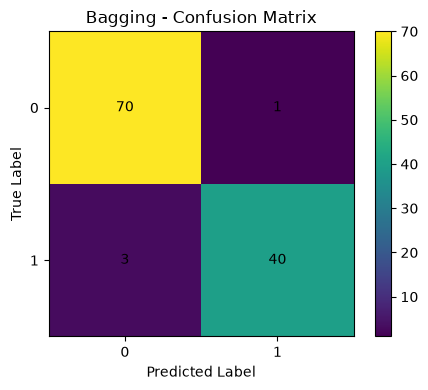


Boosting Confusion Matrix:
[[68  3]
 [ 3 40]]


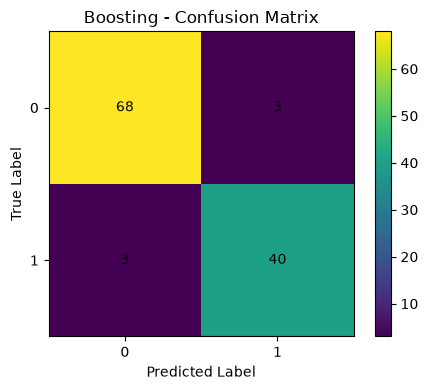


Stacked Ensemble Confusion Matrix:
[[69  2]
 [ 2 41]]


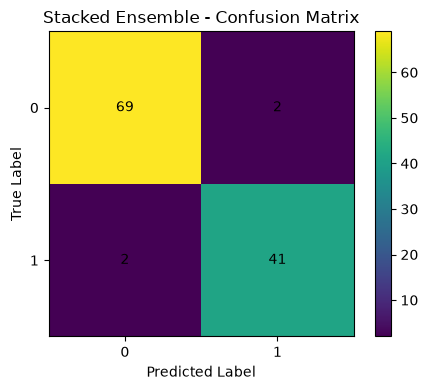

In [33]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# ============================================================
# CONFUSION MATRICES
# ============================================================

predictions = {
    "Bagging": y_pred_bagging,
    "Boosting": y_pred_boosting,
    "Stacked Ensemble": y_pred_stacking
}

for model_name, y_pred in predictions.items():

    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{model_name} Confusion Matrix:")
    print(cm)

    plt.figure(figsize=(5, 4))

    plt.imshow(cm)

    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.xticks([0, 1], ["0", "1"])
    plt.yticks([0, 1], ["0", "1"])

    # Display values inside cells
    for i in range(2):
        for j in range(2):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.colorbar()
    plt.tight_layout()
    plt.show()

In [34]:
from sklearn.metrics import roc_curve, roc_auc_score

# ============================================================
# ROC CURVE DATA
# ============================================================

probabilities = {
    "Bagging": y_prob_bagging,
    "Boosting": y_prob_boosting,
    "Stacked Ensemble": y_prob_stacking
}

roc_results = {}

for model_name, y_prob in probabilities.items():

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_prob
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    roc_results[model_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": auc
    }

    print(f"{model_name} AUC: {auc:.4f}")

Bagging AUC: 0.9948
Boosting AUC: 0.9905
Stacked Ensemble AUC: 0.9964


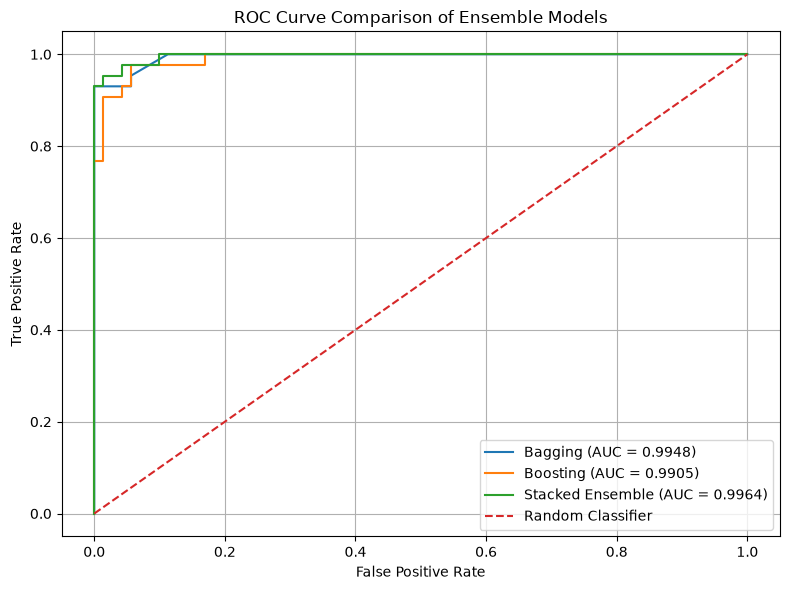

In [35]:
# ============================================================
# ROC CURVE COMPARISON
# ============================================================

plt.figure(figsize=(8, 6))

for model_name, result in roc_results.items():

    plt.plot(
        result["fpr"],
        result["tpr"],
        label=f"{model_name} (AUC = {result['auc']:.4f})"
    )

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison of Ensemble Models")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

In [36]:
# ============================================================
# AUC RESULTS
# ============================================================

auc_results = []

for model_name, result in roc_results.items():

    auc_results.append({
        "Model": model_name,
        "AUC": result["auc"]
    })

auc_table = pd.DataFrame(auc_results)

auc_table["AUC"] = auc_table["AUC"].round(4)

display(auc_table)

,Model,AUC
0,Bagging,0.9948
1,Boosting,0.9905
2,Stacked Ensemble,0.9964


# TAble Results


## Bagging

In [38]:
bagging_cv_results = pd.DataFrame(bagging_grid.cv_results_)

bagging_table = (
    bagging_cv_results.loc[
        bagging_cv_results.groupby("param_n_estimators")["mean_test_accuracy"].idxmax()
    ]
    .sort_values("param_n_estimators")
)

bagging_table = bagging_table[[
    "param_n_estimators", "param_max_samples",
    "mean_test_accuracy", "mean_test_f1"
]].copy()

bagging_table["mean_test_accuracy"] *= 100
bagging_table["mean_test_f1"] *= 100

bagging_table.columns = ["n_estimators", "max_samples", "Avg CV Accuracy (%)", "Avg CV F1 Score"]
display(bagging_table.round(2))

,n_estimators,max_samples,Avg CV Accuracy (%),Avg CV F1 Score
8,10,1.00,95.60,93.88
5,25,0.75,96.04,94.56
22,50,1.00,96.04,94.57
7,100,0.75,95.60,93.92


# Boosting

In [39]:
gb_cv_results = pd.DataFrame(gb_grid.cv_results_)

gb_table = (
    gb_cv_results.loc[
        gb_cv_results.groupby("param_n_estimators")["mean_test_accuracy"].idxmax()
    ]
    .sort_values("param_n_estimators")
)

gb_table = gb_table[[
    "param_n_estimators", "param_learning_rate",
    "mean_test_accuracy", "mean_test_f1"
]].copy()

gb_table["mean_test_accuracy"] *= 100
gb_table["mean_test_f1"] *= 100

gb_table.columns = ["n_estimators", "learning_rate", "Avg CV Accuracy (%)", "Avg CV F1 Score"]
display(gb_table.round(2))

,n_estimators,learning_rate,Avg CV Accuracy (%),Avg CV F1 Score
18,50,0.5,97.14,96.08
19,100,0.5,97.80,96.97
20,150,0.5,97.36,96.34


# Stacking

In [40]:
stacking_results_df = pd.DataFrame(stacking_results)

# Best C per base-model configuration (matches the report's 3-column table)
stacking_report_table = (
    stacking_results_df.loc[
        stacking_results_df.groupby("Base Models")["Avg CV Accuracy"].idxmax()
    ]
    .sort_values("Avg CV Accuracy", ascending=False)
    .copy()
)

stacking_report_table["Avg CV Accuracy (%)"] = stacking_report_table["Avg CV Accuracy"] * 100
stacking_report_table["Avg CV F1 Score"] = stacking_report_table["Avg CV F1"] * 100

stacking_report_table = stacking_report_table[[
    "Base Models", "Meta Learner", "Avg CV Accuracy (%)", "Avg CV F1 Score"
]]

display(stacking_report_table.round(2))

,Base Models,Meta Learner,Avg CV Accuracy (%),Avg CV F1 Score
4,SVM + Decision Tree,Logistic Regression,97.36,96.31
11,SVM + Naive Bayes + Decision Tree,Logistic Regression,97.36,96.33
2,SVM + Naive Bayes,Logistic Regression,96.92,95.82
6,Naive Bayes + Decision Tree,Logistic Regression,93.63,90.78


# Performance comparison

In [41]:
performance_table_display = performance_table.copy()
performance_table_display[["Precision", "Recall", "F1 Score"]] *= 100
performance_table_display = performance_table_display.round(2)
display(performance_table_display)

,Model,Accuracy (%),Precision,Recall,F1 Score
0,Bagging,96.49,97.56,93.02,95.24
1,Boosting,94.74,93.02,93.02,93.02
2,Stacked Ensemble,96.49,95.35,95.35,95.35
